In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns

plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8')
plt.rcParams.update({
    'font.serif': 'Times New Roman',
    'axes.unicode_minus': False,
    'font.size': 12,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'mathtext.fontset': 'stix'
})
sns.set_palette("husl")
seed = 42
np.random.seed(seed)

high_path = r'C:\Users\h\Desktop\小论文\BDI1000\BO-滤波-GPR\CEEMDAN高频预测结果.xlsx'
high_pred = pd.read_excel(high_path, sheet_name='分组预测')
high_pred_train = high_pred.iloc[:, 0].values
high_pred_test = high_pred.iloc[:, 1].values

low_path = r'C:\Users\h\Desktop\小论文\BDI1000\BO-滤波-GPR\CEEMDAN低频预测结果.xlsx'
low_pred = pd.read_excel(low_path, sheet_name='分组预测')
low_pred_train = low_pred.iloc[:, 0].values
low_pred_test = low_pred.iloc[:, 1].values

scfis_path = r'C:\Users\h\Desktop\小论文\BDI1000\BDI.xlsx'
scfis = pd.read_excel(scfis_path)
time_real = pd.to_datetime(scfis.iloc[:, 0])
real_series = scfis.iloc[:, 1].values

n_train = len(high_pred_train)
n_test = len(high_pred_test)
train_real_start = 5
train_real_end = 5 + n_train
test_real_start = len(real_series) - n_test
test_real_end = len(real_series)
final_pred = np.concatenate([
    high_pred_train + low_pred_train,
    high_pred_test + low_pred_test
])
real_series_aligned = np.concatenate([
    real_series[train_real_start:train_real_end],
    real_series[test_real_start:test_real_end]
])
time_aligned = np.concatenate([
    time_real[train_real_start:train_real_end],
    time_real[test_real_start:test_real_end]
])
result_df = pd.DataFrame({
    '时间': time_aligned,
    '真实值': real_series_aligned,
    '最终预测值': final_pred
})
result_df = result_df.dropna().reset_index(drop=True)
low_pred = pd.read_excel(low_path, sheet_name='完整预测')
high_pred = pd.read_excel(high_path, sheet_name='完整预测')
new_real_series1 = low_pred.iloc[:len(result_df), 0].values
new_real_series2 = high_pred.iloc[:len(result_df), 0].values
new_real_series=new_real_series1+new_real_series2
result_df['真实值'] = new_real_series
print(result_df)

start_date = pd.to_datetime('2021-05-18')
end_date = pd.to_datetime('2024-04-18')
mask = (result_df['时间'] >= start_date) & (result_df['时间'] <= end_date)
df_filtered = result_df.loc[mask].reset_index(drop=True)

y_true = df_filtered['真实值'].values
y_pred = df_filtered['最终预测值'].values

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
if np.any(y_true == 0):
    mape = np.nan
else:
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)
y_true_diff = np.diff(y_true)
y_pred_diff = np.diff(y_pred)
correct_directions = np.sign(y_true_diff) == np.sign(y_pred_diff)
dr = np.mean(correct_directions) * 100

print(f"\n[{start_date.date()}至{end_date.date()} 结果]")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.4f}%")
print(f"R²: {r2:.4f}")
print(f"DR: {dr:.4f}%")


             时间          真实值        最终预测值
0    2021-05-18  2816.058369  2816.027444
1    2021-05-19  2807.679841  2812.157978
2    2021-05-20  2829.157495  2831.225345
3    2021-05-21  2855.980928  2856.765964
4    2021-05-24  2856.182195  2859.310251
...         ...          ...          ...
1036 2025-07-17  2005.400872  2006.831054
1037 2025-07-18  2039.850821  2056.606591
1038 2025-07-21  2045.882921  2047.612625
1039 2025-07-22  2063.417475  2047.398061
1040 2025-07-23  2085.112212  2088.249573

[1041 rows x 3 columns]

[2021-05-18至2024-04-18 结果]
MSE: 15.4172
RMSE: 3.9265
MAE: 2.9454
MAPE: 0.1595%
R²: 1.0000
DR: 96.6942%


In [18]:
high_path = r'C:\Users\h\Desktop\小论文\BDI1000\BO-滤波-GPR\CEEMDAN高频预测结果.xlsx'
high_pred = pd.read_excel(high_path, sheet_name='分组预测')
high_pred_train = high_pred.iloc[:, 0].values  
high_pred_test = high_pred.iloc[:, 1].values   

low_path = r'C:\Users\h\Desktop\小论文\BDI1000\BO-滤波-GPR\CEEMDAN低频预测结果.xlsx'
low_pred = pd.read_excel(low_path, sheet_name='分组预测')
low_pred_train = low_pred.iloc[:, 0].values    
low_pred_test = low_pred.iloc[:, 1].values     

scfis_path = r'C:\Users\h\Desktop\小论文\BDI1000\BDI.xlsx'
scfis = pd.read_excel(scfis_path)
time_real = pd.to_datetime(scfis.iloc[:, 0])   
real_series = scfis.iloc[:, 1].values          

n_train = len(high_pred_train)
n_test = len(high_pred_test)
total_pred_len = n_train + n_test
train_real_start = 5
train_real_end = 5 + n_train  
test_real_start = len(real_series) - n_test
test_real_end = len(real_series)   
final_pred = np.concatenate([high_pred_train + low_pred_train, high_pred_test + low_pred_test])
final_pred_aligned = np.concatenate([high_pred_train + low_pred_train, high_pred_test + low_pred_test])
real_series_aligned = np.concatenate([real_series[train_real_start:train_real_end], real_series[test_real_start:test_real_end]])
time_aligned = np.concatenate([time_real[train_real_start:train_real_end], time_real[test_real_start:test_real_end]])
result_df = pd.DataFrame({
    '时间': time_aligned,
    '真实值': real_series_aligned,
    '最终预测值': final_pred
})
result_df = result_df.dropna().reset_index(drop=True)
print(result_df)
start_date = pd.to_datetime('2024-04-19')
end_date = pd.to_datetime('2025-07-23')
mask = (result_df['时间'] >= start_date) & (result_df['时间'] <= end_date)
df_filtered = result_df.loc[mask].reset_index(drop=True)
y_true = df_filtered['真实值'].values
y_pred = df_filtered['最终预测值'].values

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

if np.any(y_true == 0):
    mape = np.nan
else:
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

r2 = r2_score(y_true, y_pred)

y_true_diff = np.diff(y_true)
y_pred_diff = np.diff(y_pred)
correct_directions = np.sign(y_true_diff) == np.sign(y_pred_diff)
dr = np.mean(correct_directions) * 100

print(f"\n[{start_date.date()}至{end_date.date()} 结果]")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.4f}%")
print(f"R²: {r2:.4f}")
print(f"DR: {dr:.4f}%")


             时间   真实值        最终预测值
0    2021-05-18  2795  2816.027444
1    2021-05-19  2801  2812.157978
2    2021-05-20  2824  2831.225345
3    2021-05-21  2869  2856.765964
4    2021-05-24  2881  2859.310251
...         ...   ...          ...
1036 2025-07-17  2030  2006.831054
1037 2025-07-18  2052  2056.606591
1038 2025-07-21  2016  2047.612625
1039 2025-07-22  2035  2047.398061
1040 2025-07-23  2120  2088.249573

[1041 rows x 3 columns]

[2024-04-19至2025-07-23 结果]
MSE: 238.6906
RMSE: 15.4496
MAE: 11.5435
MAPE: 0.7417%
R²: 0.9982
DR: 84.9840%


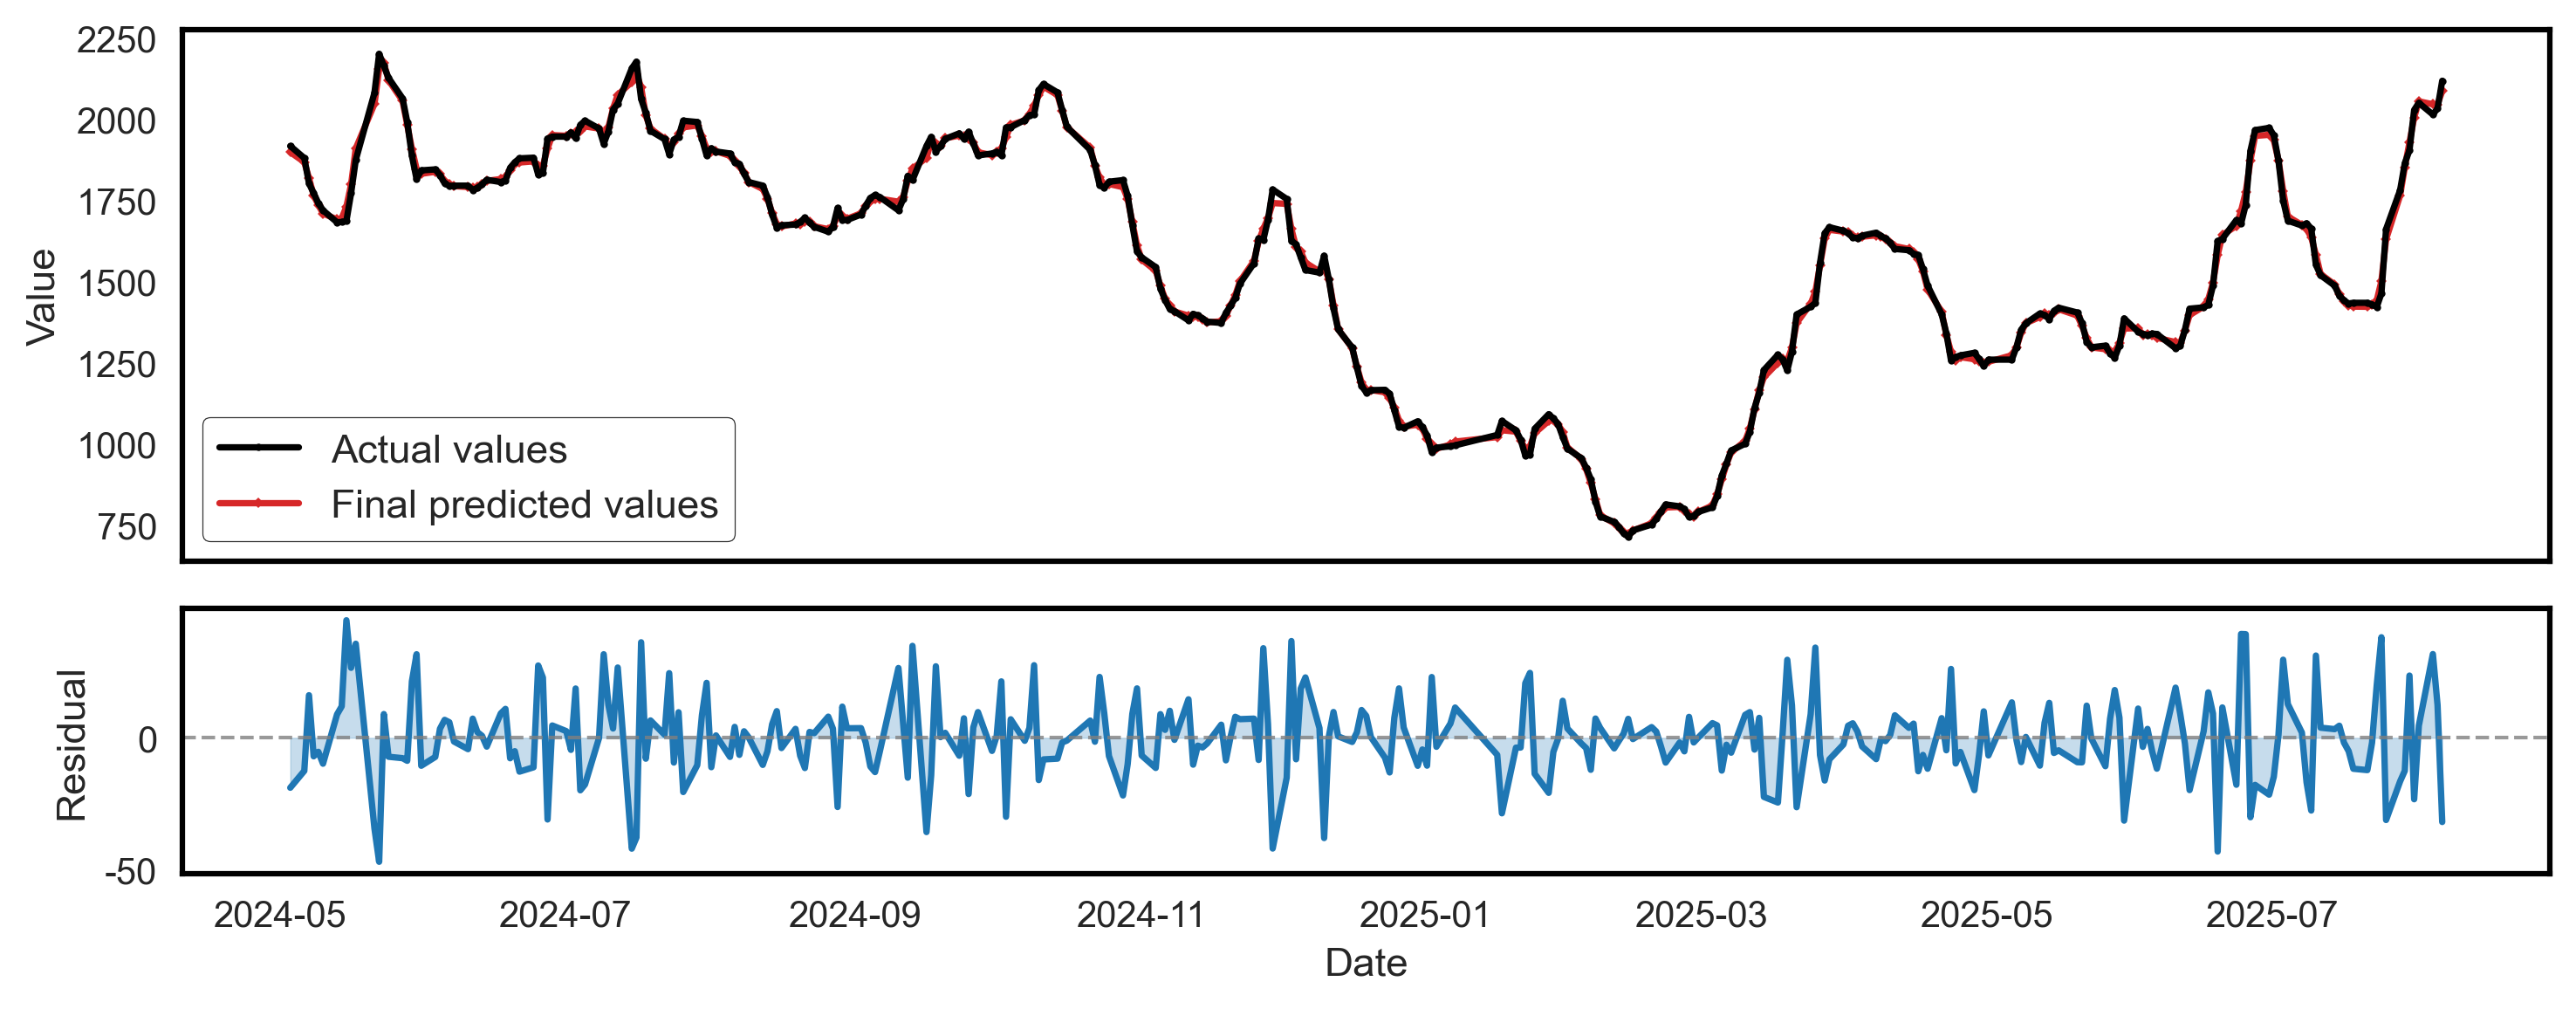

In [19]:
df_filtered['误差'] = df_filtered['最终预测值'] - df_filtered['真实值']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,4),dpi=300, gridspec_kw={'height_ratios': [4,2]}, sharex=True)
plt.subplots_adjust(hspace=0.15)

ax1.plot(df_filtered['时间'], df_filtered['真实值'], color='black', label='Actual values',
         marker='o', markersize=2, markevery=1, zorder=3)
ax1.plot(df_filtered['时间'], df_filtered['最终预测值'], color='tab:red', label='Final predicted values',
         marker='D', markersize=2, markevery=1, zorder=2)

ax1.set_ylabel('Value')
ax1.legend(frameon=True, facecolor='white', edgecolor='black', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(df_filtered['时间'], df_filtered['误差'], color='tab:blue', linestyle='-', label='Residual')
ax2.fill_between(df_filtered['时间'], df_filtered['误差'], 0, color='tab:blue', alpha=0.25, label='Residual interval')
ax2.axhline(0, color='gray', linestyle='--', lw=1, alpha=0.8)
ax2.set_ylabel('Residual')
ax2.set_xlabel('Date')
ax2.grid(True, linestyle='--', alpha=0.4)

fig.autofmt_xdate(rotation=0)
plt.tight_layout()
plt.savefig(r'C:\Users\h\Desktop\小论文\BDI1000\Fig13.pdf', format='pdf', dpi=300)
plt.show()

save_df = df_filtered[['时间', '真实值', '最终预测值', '误差']]

save_df.to_excel(r'C:\Users\h\Desktop\小论文\BDI1000\BO-滤波-GPR\误差.xlsx', index=False, header=['时间', '真实值', '最终预测值', '误差'])


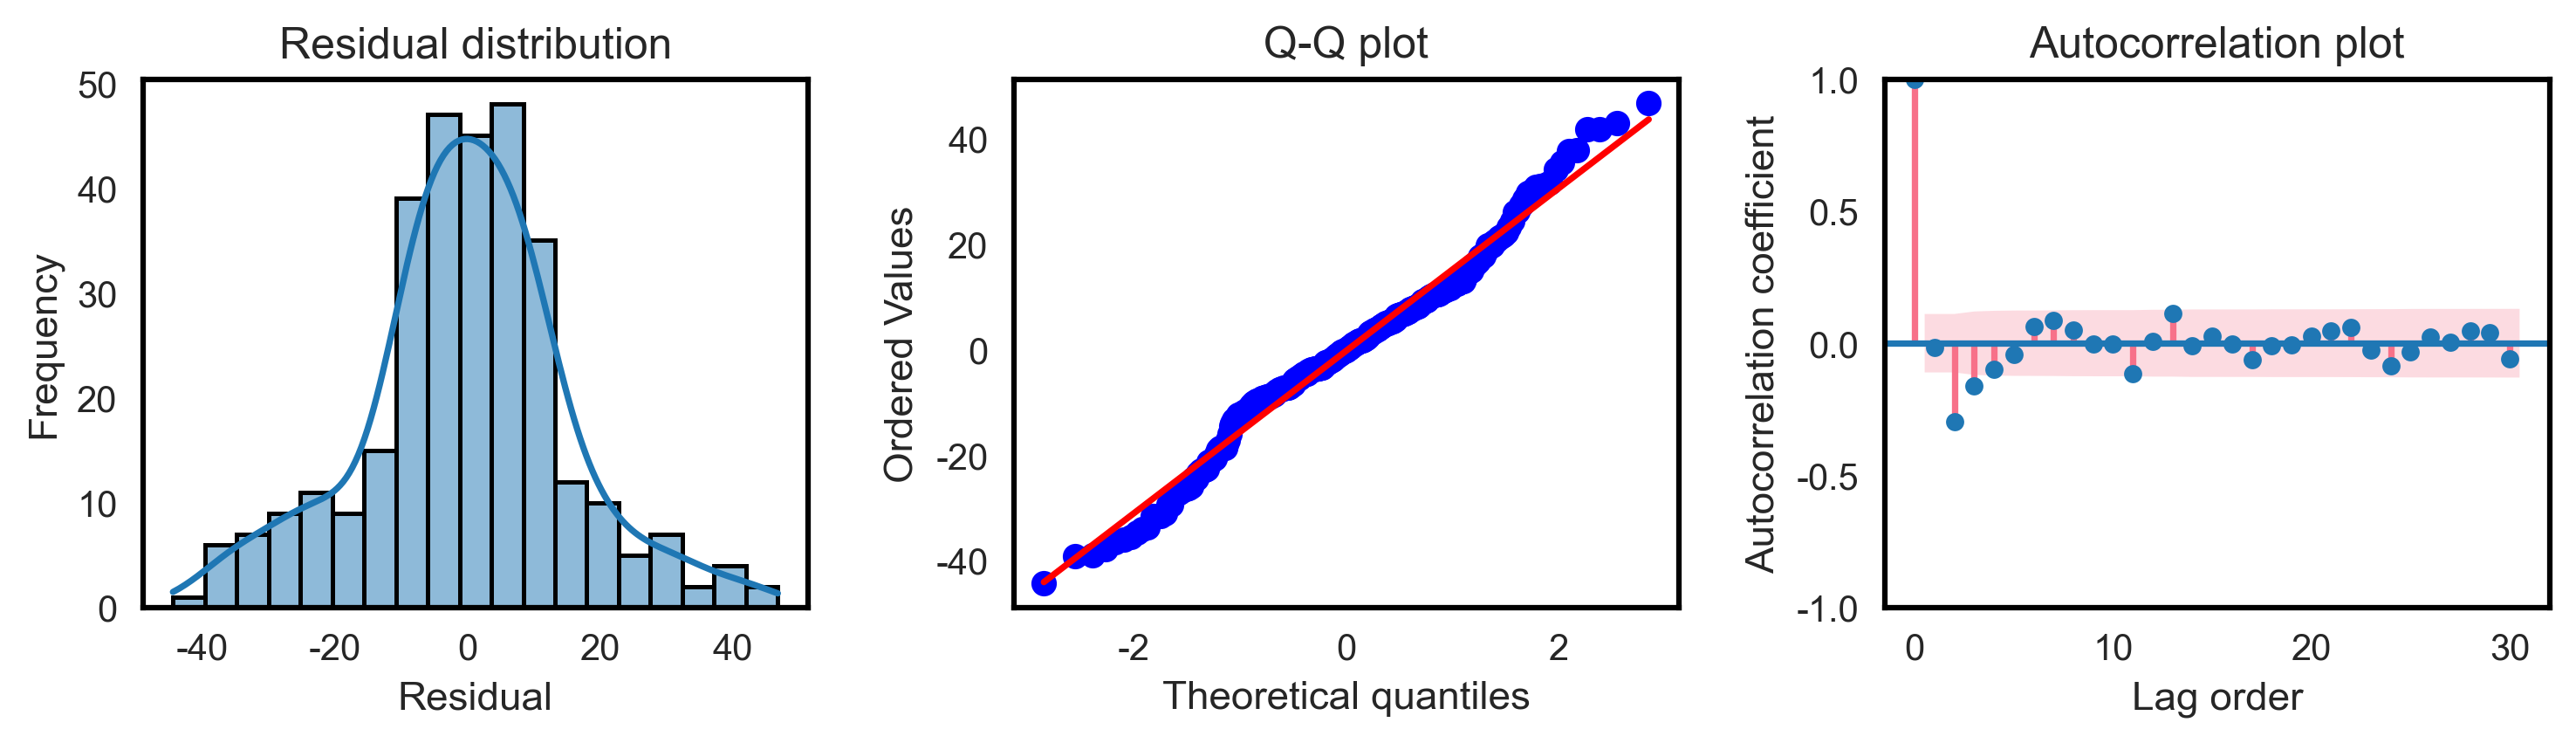

In [20]:
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

residuals = df_filtered['真实值'] - df_filtered['最终预测值']

plt.figure(figsize=(10, 3),dpi=300)

plt.subplot(1,3,1)
sns.histplot(residuals, kde=True, color='tab:blue', edgecolor='black', linewidth=1.2)
plt.title("Residual distribution")
plt.ylabel("Frequency")
plt.xlabel("Residual")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1,3,2)
stats.probplot(residuals, plot=plt)
plt.title("Q-Q plot")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1,3,3)
plot_acf(residuals, lags=30, ax=plt.gca(), color='tab:blue')
plt.title("Autocorrelation plot")
plt.ylabel("Autocorrelation coefficient")
plt.xlabel("Lag order")

plt.tight_layout()
plt.savefig(r'C:\Users\h\Desktop\小论文\BDI1000\Fig14.pdf', format='pdf', dpi=300)
plt.show()